In [ ]:
import sys, json
sys.path.append('..') 

from scripts.constants import *

import ee, eemont
import pandas as pd

In [ ]:
# Trigger the authentication flow.
ee.Authenticate()
# Initialize the library.
ee.Initialize(project=GEE_PROJECT_NAME, opt_url='https://earthengine-highvolume.googleapis.com')

/maps/acz25/miniconda3/envs/3-30-300-env/lib/python3.10/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 43009 instead
  warnings.warn(


In [26]:
imd_lsoa_bua_boundaries_ee = ee.FeatureCollection("projects/ee-phd-thesis/assets/English_IMD_2019_BUA_filtered_boundaries")
imagery="COPERNICUS/S2_HARMONIZED"
cloud_coverage=10
start_date="2024-01-01"
end_date="2024-12-31"
england_boundaries = ee.FeatureCollection("FAO/GAUL/2015/level1") \
    .filter(ee.Filter.eq('ADM1_NAME', 'England'))
england_geometry = england_boundaries.geometry()

# Request Sentinel-2 data with low cloud coverage
image_collection = (ee.ImageCollection(imagery) \
    .filterDate(start_date, end_date) \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', cloud_coverage)) \
    .filterBounds(england_geometry) \
    .spectralIndices(['NDVI','NDWI','NDBI']).median() \
    .select(['NDVI','NDWI','NDBI']))

In [5]:
# Function to calculate mean NDVI for each feature
def calculate_median_index(image_collection, geometries, scale=10, tile_scale=1):
    mean_dict = image_collection.reduceRegions(
        collection=geometries,
        reducer=ee.Reducer.median(), scale=scale, tileScale=tile_scale
    )
    return mean_dict

In [27]:
# List to store results
spectral_results_lst = []
# Iterate over each band
# bands = ['NDVI', 'NDWI', 'NDBI']
# for band in bands:
#     image_collection = sentinel2_collection
    # Iterate over every 1000 geometries
for i in range(0, imd_lsoa_bua_boundaries_ee.size().getInfo(), 1000):
    limited_geometries = imd_lsoa_bua_boundaries_ee.toList(1000, i)
    limited_geometries_fc = ee.FeatureCollection(limited_geometries)
    mean_index_features = calculate_median_index(image_collection, limited_geometries_fc)
    mean_index_dict = mean_index_features.getInfo()['features']
    temp_features = [row['properties'] for row in mean_index_dict]
    spectral_results_lst.extend(temp_features)

    if i == 1000:
        break
    # for item in spectral_results[band]:
    #     item[band] = item.pop('median')
    #     item[band] = round(item[band], 3)

# Print the results
spectral_results_lst

[{'BUA22CD': 'E63000242',
  'BUA22NM': 'Hartlepool',
  'BUA22NMG': '',
  'BUA22NMW': '',
  'LAD22CD': 'E06000001',
  'LAD22NM': 'Hartlepool',
  'LAD22NMW': '',
  'LSOA11CD': 'E01032540',
  'LSOA11NM': 'Hartlepool 003G',
  'LSOA21CD': 'E01032540',
  'LSOA21NM': 'Hartlepool 003G',
  'LSOA21NMW': '',
  'NDBI': -0.09587290862074799,
  'NDVI': 0.2831690838104213,
  'NDWI': -0.19727840539117386,
  'RGN22CD': 'E12000001',
  'RGN22NM': 'North East',
  'RGN22NMW': ''},
 {'BUA22CD': 'E63000242',
  'BUA22NM': 'Hartlepool',
  'BUA22NMG': '',
  'BUA22NMW': '',
  'LAD22CD': 'E06000001',
  'LAD22NM': 'Hartlepool',
  'LAD22NMW': '',
  'LSOA11CD': 'E01032541',
  'LSOA11NM': 'Hartlepool 003H',
  'LSOA21CD': 'E01032541',
  'LSOA21NM': 'Hartlepool 003H',
  'LSOA21NMW': '',
  'NDBI': -0.11128061087329504,
  'NDVI': 0.3264079540233536,
  'NDWI': -0.22450389989169975,
  'RGN22CD': 'E12000001',
  'RGN22NM': 'North East',
  'RGN22NMW': ''},
 {'BUA22CD': 'E63000242',
  'BUA22NM': 'Hartlepool',
  'BUA22NMG': '',

<Axes: >

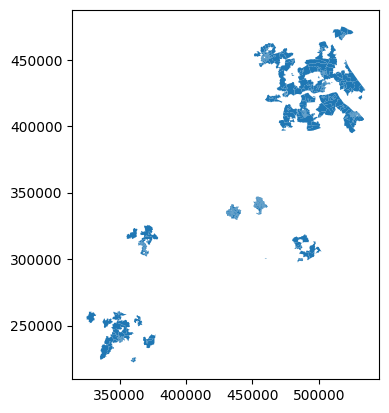

In [42]:
spectral_index_gdf.plot()

In [41]:
import geopandas as gpd
from shapely.geometry import shape

geometry = [shape(feature['geometry']) for feature in mean_index_dict]
properties = [feature['properties'] for feature in mean_index_dict]

spectral_index_gdf = gpd.GeoDataFrame(properties, geometry=geometry, crs='EPSG:4326').to_crs('EPSG:27700')

# Print the GeoDataFrame
spectral_index_gdf

,BUA22CD,BUA22NM,BUA22NMG,BUA22NMW,LAD22CD,LAD22NM,LAD22NMW,LSOA11CD,LSOA11NM,LSOA21CD,LSOA21NM,LSOA21NMW,NDBI,NDVI,NDWI,RGN22CD,RGN22NM,RGN22NMW,geometry
0,E63000825,Kingston upon Hull,,,E06000010,Kingston upon Hull,,E01012912,Kingston upon Hull 006E,E01012912,Kingston upon Hull 006E,,0.005625,0.189544,-0.146796,E12000003,Yorkshire and The Humber,,"POLYGON ((510250.865 433101.406, 510122.785 43..."
1,E63000825,Kingston upon Hull,,,E06000010,Kingston upon Hull,,E01012913,Kingston upon Hull 014E,E01012913,Kingston upon Hull 014E,,-0.091731,0.240283,-0.173521,E12000003,Yorkshire and The Humber,,"POLYGON ((506997.198 431657.273, 507138.187 43..."
2,E63000825,Kingston upon Hull,,,E06000010,Kingston upon Hull,,E01012914,Kingston upon Hull 012C,E01012914,Kingston upon Hull 012C,,-0.076239,0.232657,-0.177860,E12000003,Yorkshire and The Humber,,"POLYGON ((508663.247 431765.49, 508578.851 431..."
3,E63000825,Kingston upon Hull,,,E06000010,Kingston upon Hull,,E01012915,Kingston upon Hull 008E,E01012915,Kingston upon Hull 008E,,-0.068855,0.283074,-0.216751,E12000003,Yorkshire and The Humber,,"POLYGON ((507203.72 433039.852, 507237.971 432..."
4,E63000825,Kingston upon Hull,,,E06000010,Kingston upon Hull,,E01012916,Kingston upon Hull 012D,E01012916,Kingston upon Hull 012D,,-0.095649,0.310140,-0.216515,E12000003,Yorkshire and The Humber,,"POLYGON ((508465.665 432675.465, 508338.081 43..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,E63002505,Telford,,,E06000020,Telford and Wrekin,,E01014165,Telford and Wrekin 017D,E01014165,Telford and Wrekin 017D,,-0.122978,0.314477,-0.232544,E12000005,West Midlands,,"POLYGON ((369459.653 308989.019, 369204.982 30..."
996,E63002505,Telford,,,E06000020,Telford and Wrekin,,E01014166,Telford and Wrekin 017E,E01014166,Telford and Wrekin 017E,,-0.115157,0.294881,-0.228656,E12000005,West Midlands,,"POLYGON ((368682.227 307668.99, 368711.018 307..."
997,E63002505,Telford,,,E06000020,Telford and Wrekin,,E01014167,Telford and Wrekin 004B,E01014167,Telford and Wrekin 004B,,-0.162101,0.388778,-0.306537,E12000005,West Midlands,,"POLYGON ((372578.314 314683.168, 372498.385 31..."
998,E63002505,Telford,,,E06000020,Telford and Wrekin,,E01014168,Telford and Wrekin 004C,E01014168,Telford and Wrekin 004C,,-0.099423,0.283326,-0.200974,E12000005,West Midlands,,"POLYGON ((370862.121 314365.948, 370926.158 31..."
